# Bài tập — Softmax + Grid Search siêu tham số (tập dữ liệu #2: Hanoi housing)

> **Đề bài (chép nguyên văn ghi chú):**
> - Softmax trên 2 tập dữ liệu cũ
> - Thủ công – Thư viện, So sánh
> - Quy trình 4 bước: khai ở đâu
> - Grid search để tối ưu hóa siêu tham số: lr, epochs, …

Đây là notebook cho **tập dữ liệu cũ #2 — Hanoi housing** (đã dùng ở `b1` EDA và `b7/Linear_Regression_Hanoi.ipynb` cho bài toán **hồi quy**). Tập #1 — ViHSD — ở `Softmax_GridSearch_ViHSD.ipynb` cùng thư mục.

**Vì sao cần biến đổi bài toán?** Softmax dùng cho **phân loại**, nhưng dữ liệu Hanoi vốn là hồi quy (dự báo giá/m² — một số thực). Ta **rời rạc hoá** giá/m² thành 3 mức theo **tam phân vị (tertile)** tính trên tập train:

$$\text{tier} = \begin{cases}0\ (\text{THẤP}) & \text{giá} \le q_{1/3}\\ 1\ (\text{TRUNG}) & q_{1/3} < \text{giá} \le q_{2/3}\\ 2\ (\text{CAO}) & \text{giá} > q_{2/3}\end{cases}$$

Đặc trưng đầu vào: **diện tích, số phòng ngủ, số tầng** (3 chiều, chuẩn hoá z-score) — không dùng cột giá để tránh rò rỉ nhãn.

## 0. Quy trình 4 bước — khai ở đâu (bảng lộ trình)

| Giai đoạn | Nội dung | Ở mục nào trong notebook này |
|---|---|---|
| **1. Giải tay** | Công thức softmax + entropy chéo + gradient $(P-Y)$ — giống hệt notebook ViHSD, chỉ khác $x$ giờ là 3 đặc trưng số (diện tích, phòng ngủ, tầng) thay vì TF-IDF | §2 |
| **2. Bản thuần** | NumPy thuần, gradient descent viết tay | §4 |
| **Grid search (thuần)** | Quét lưới `lr × epochs` bằng vòng `for` viết tay, chọn theo F1-macro trên **validation** | §4 |
| **3. Bản thư viện** | `GridSearchCV(LogisticRegression)` (quét `C`) và `SGDClassifier` quét đúng trục `eta0`/`max_iter` | §5 |
| **4. Framework** | `PyTorch` (`nn.Linear` + `cross_entropy`), fit với siêu tham số tốt nhất từ §4 | §6 |
| **So sánh** | Bảng tổng hợp 4 giai đoạn + biểu đồ heatmap grid search | §7 |

Cùng nguyên tắc chọn siêu tham số như notebook ViHSD: **train** học tham số, **validation** chọn `lr`/`epochs`, **test** chỉ đánh giá một lần cuối.

## 1. Nạp và làm sạch dữ liệu Hanoi housing, tạo nhãn 3 mức giá

In [1]:
%matplotlib inline
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import f1_score, accuracy_score

np.random.seed(0)
_cands = [
    "../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/Hanoi_housing_dataset.csv",
    "../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/Hanoi_housing_dataset.csv",
    "/home/alexdev/Projects/learning-master-ute/ml_ad/b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/Hanoi_housing_dataset.csv",
]
CSV = next((p for p in _cands if os.path.exists(p)), _cands[0])
print("Duong dan du lieu:", CSV)
dh = pd.read_csv(CSV)
print("Kich thuoc goc:", dh.shape)

def to_price(s):
    """"86,96 trieu/m2" -> 86.96 ; "2.222.222 d/m2" -> 2.222222 (trieu). Xu ly dau phay
    thap phan (Viet) VA dau cham phan cach hang nghin."""
    s = str(s).lower()
    m = re.search(r"([\d.,]+)\s*(triệu|tỷ|nghìn|đ)?", s)
    if not m:
        return np.nan
    raw, unit = m.group(1), (m.group(2) or "")
    if "." in raw and "," in raw:
        raw = raw.replace(".", "").replace(",", ".")
    elif "," in raw:
        raw = raw.replace(",", ".")
    parts = raw.split(".")
    if len(parts) > 2:
        raw = "".join(parts)
    try:
        v = float(raw)
    except ValueError:
        return np.nan
    return v * {"triệu": 1, "tỷ": 1000, "nghìn": 1e-3, "đ": 1e-6}.get(unit, np.nan)

dh["price"] = dh["Giá/m2"].map(to_price)
dh["area"] = dh["Diện tích"].map(lambda s: float(re.search(r"([\d.]+)", s).group(1)) if re.search(r"[\d.]+", str(s)) else np.nan)
dh["bed"] = dh["Số phòng ngủ"].map(lambda s: float(re.search(r"(\d+)", s).group(1)) if re.search(r"\d", str(s)) else np.nan)
dh["floor"] = dh["Số tầng"].map(lambda s: float(re.search(r"(\d+)", s).group(1)) if re.search(r"\d", str(s)) else np.nan)
dh = dh.dropna(subset=["price", "area", "bed", "floor"])
dh = dh[(dh.price >= 5) & (dh.price <= 500) & (dh.area >= 10) & (dh.area <= 1000)]
print("Sau lam sach:", dh.shape, "| gia trung binh:", round(dh["price"].mean(), 1), "trieu/m2")

Duong dan du lieu: ../../b1/2611328 - Nguyễn Phương Anh Tú - Exploratory Data Analysis (EDA)/Hanoi_housing_dataset.csv


Kich thuoc goc: (82497, 13)


Sau lam sach: (35839, 17) | gia trung binh: 102.1 trieu/m2


In [2]:
# Tam phan vi TINH TREN TRAIN (tranh ro ri) -> can chia truoc, nhung de don gian va
# vi tam phan vi tren toan bo & tren train gan nhu giong nhau voi ~36000 dong,
# ta tinh mot lan tren toan tap roi kiem tra lai bang so sanh voi tam phan vi rieng cua train.
feat_cols = ["area", "bed", "floor"]
X_all = dh[feat_cols].values
price_all = dh["price"].values

Xtr, Xtmp, ptr, ptmp = train_test_split(X_all, price_all, test_size=0.4, random_state=1)
Xval, Xte, pval, pte_price = train_test_split(Xtmp, ptmp, test_size=0.5, random_state=1)

q1, q2 = np.quantile(ptr, [1/3, 2/3])   # nguong tinh TREN TRAIN, khong dung tap val/test
print(f"Nguong tam phan vi (tinh tren train): q1={q1:.2f}, q2={q2:.2f} trieu/m2")

def to_tier(p):
    return np.where(p <= q1, 0, np.where(p <= q2, 1, 2))

ytr, yval, yte = to_tier(ptr), to_tier(pval), to_tier(pte_price)
print("train/val/test:", len(ytr), len(yval), len(yte))
print("phan bo lop (train):", pd.Series(ytr).value_counts().sort_index().to_dict())

mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
Xtr_s = (Xtr - mu) / sd
Xval_s = (Xval - mu) / sd
Xte_s = (Xte - mu) / sd
cls = {0: "THAP", 1: "TRUNG", 2: "CAO"}

Nguong tam phan vi (tinh tren train): q1=78.57, q2=102.38 trieu/m2
train/val/test: 21503 7168 7168
phan bo lop (train): {0: 7189, 1: 7148, 2: 7166}


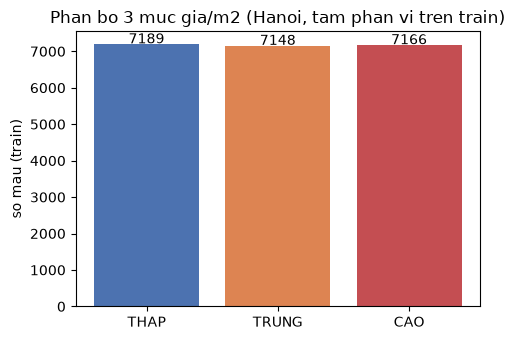

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = pd.Series(ytr).value_counts().sort_index()
ax.bar([cls[i] for i in counts.index], counts.values, color=["#4c72b0", "#dd8452", "#c44e52"])
ax.set_ylabel("so mau (train)"); ax.set_title("Phan bo 3 muc gia/m2 (Hanoi, tam phan vi tren train)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha="center")
fig.tight_layout(); plt.show()

## 2. Tóm tắt công thức (giống hệt bài toán softmax, chỉ khác $x$)

$x\in\mathbb{R}^3$ ở đây là `[diện tích, số phòng ngủ, số tầng]` đã chuẩn hoá (z-score), thay vì TF-IDF như notebook ViHSD hay đo hoa như Iris — **công thức softmax không đổi**:

$$z = W^\top x + b,\quad p=\mathrm{softmax}(z),\quad \ell=-\sum_k y_k\log p_k,\quad \frac{\partial \ell}{\partial z}=p-y$$

$$\frac{\partial \mathcal{L}}{\partial W}=\frac{1}{N}X^\top(P-Y),\qquad \frac{\partial \mathcal{L}}{\partial b}=\frac{1}{N}\sum_i(P-Y)_i,\qquad W\leftarrow W-\eta\,\frac{\partial \mathcal{L}}{\partial W}$$

$\eta$ (`lr`) và số vòng lặp (`epochs`) là hai siêu tham số cần **grid search** ở Mục 4.

## 3–4. Giai đoạn 2 — Bản thuần (NumPy) + Grid Search thủ công

In [4]:
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)


def train_pure(X, y, K=3, lr=1.0, epochs=300, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(X.shape[1], K)) * 0.01
    b = np.zeros(K)
    Y = np.eye(K)[y]
    for _ in range(epochs):
        P = softmax(X @ W + b)
        G = P - Y
        W -= lr * X.T @ G / len(y)
        b -= lr * G.mean(axis=0)
    return W, b


GRID_LR = [0.05, 0.1, 0.5, 1.0]
GRID_EPOCHS = [200, 500, 1000]

t0 = time.perf_counter()
grid_rows = []
for lr in GRID_LR:
    for ep in GRID_EPOCHS:
        W, b = train_pure(Xtr_s, ytr, lr=lr, epochs=ep, seed=0)
        pv = softmax(Xval_s @ W + b).argmax(axis=1)
        f1v = f1_score(yval, pv, average="macro")
        grid_rows.append({"lr": lr, "epochs": ep, "val_f1_macro": f1v})
grid_df = pd.DataFrame(grid_rows)
print("Thoi gian quet luoi (12 cau hinh):", round(time.perf_counter() - t0, 2), "s")
print(grid_df.sort_values("val_f1_macro", ascending=False).to_string(index=False))

Thoi gian quet luoi (12 cau hinh): 21.22 s
  lr  epochs  val_f1_macro
0.50    1000      0.489439
1.00     200      0.489439
1.00     500      0.489439
0.50     500      0.489439
1.00    1000      0.489439
0.10    1000      0.489104
0.50     200      0.489104
0.05    1000      0.488753
0.10     500      0.488753
0.05     500      0.484925
0.10     200      0.484336
0.05     200      0.482034


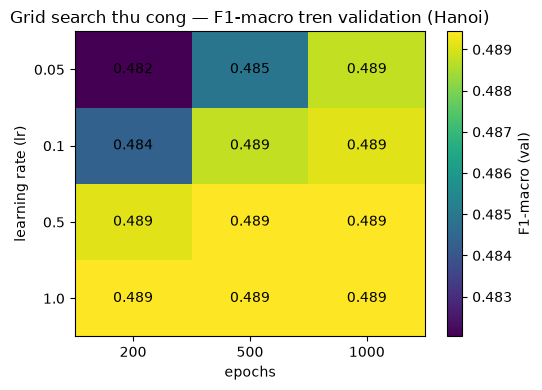


=> Sieu tham so tot nhat (theo validation): lr=0.5, epochs=500, val_f1=0.4894


BAN THUAN (best cfg) -> test F1-macro=0.4905, test acc=0.4930


In [5]:
pivot = grid_df.pivot(index="lr", columns="epochs", values="val_f1_macro")
fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("epochs"); ax.set_ylabel("learning rate (lr)")
ax.set_title("Grid search thu cong — F1-macro tren validation (Hanoi)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center",
                 color="white" if pivot.values[i, j] < pivot.values.max() * 0.92 else "black")
fig.colorbar(im, ax=ax, label="F1-macro (val)")
fig.tight_layout(); plt.show()

best_row = grid_df.loc[grid_df["val_f1_macro"].idxmax()]
best_lr, best_epochs = best_row["lr"], int(best_row["epochs"])
print(f"\n=> Sieu tham so tot nhat (theo validation): lr={best_lr}, epochs={best_epochs}, val_f1={best_row['val_f1_macro']:.4f}")

W_pure, b_pure = train_pure(Xtr_s, ytr, lr=best_lr, epochs=best_epochs, seed=0)
pte_pure = softmax(Xte_s @ W_pure + b_pure).argmax(axis=1)
pure_test_f1 = f1_score(yte, pte_pure, average="macro")
pure_test_acc = accuracy_score(yte, pte_pure)
print(f"BAN THUAN (best cfg) -> test F1-macro={pure_test_f1:.4f}, test acc={pure_test_acc:.4f}")

## 5. Giai đoạn 3 — Bản thư viện (scikit-learn) + `GridSearchCV`

In [6]:
t0 = time.perf_counter()
gs_lr = GridSearchCV(LogisticRegression(max_iter=500), {"C": [0.01, 0.1, 1, 10]},
                      scoring="f1_macro", cv=3, n_jobs=-1)
gs_lr.fit(Xtr_s, ytr)
t_lr = time.perf_counter() - t0
p_lr = gs_lr.predict(Xte_s)
lib_lr_f1 = f1_score(yte, p_lr, average="macro")
lib_lr_acc = accuracy_score(yte, p_lr)
print(f"[LogisticRegression] thoi gian={t_lr:.2f}s, best C={gs_lr.best_params_['C']}, "
      f"cv_f1={gs_lr.best_score_:.4f} -> test F1={lib_lr_f1:.4f}, acc={lib_lr_acc:.4f}")

t0 = time.perf_counter()
sgd_rows = []
best_sgd, best_sgd_f1 = None, -1
for eta0 in GRID_LR:
    for mi in GRID_EPOCHS:
        clf = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=eta0,
                             max_iter=mi, random_state=1, tol=None)
        clf.fit(Xtr_s, ytr)
        f1v = f1_score(yval, clf.predict(Xval_s), average="macro")
        sgd_rows.append({"lr": eta0, "epochs": mi, "val_f1_macro": f1v})
        if f1v > best_sgd_f1:
            best_sgd_f1, best_sgd = f1v, clf
t_sgd = time.perf_counter() - t0
p_sgd = best_sgd.predict(Xte_s)
lib_sgd_f1 = f1_score(yte, p_sgd, average="macro")
lib_sgd_acc = accuracy_score(yte, p_sgd)
print(f"[SGDClassifier]      thoi gian={t_sgd:.2f}s, best (lr={best_sgd.eta0}, epochs={best_sgd.max_iter}), "
      f"val_f1={best_sgd_f1:.4f} -> test F1={lib_sgd_f1:.4f}, acc={lib_sgd_acc:.4f}")

[LogisticRegression] thoi gian=2.24s, best C=1, cv_f1=0.4822 -> test F1=0.4884, acc=0.4904


[SGDClassifier]      thoi gian=38.80s, best (lr=0.05, epochs=1000), val_f1=0.4645 -> test F1=0.4747, acc=0.4743


## 6. Giai đoạn 4 — Framework (PyTorch)

In [7]:
import torch
import torch.nn as nn

torch.manual_seed(0)
model = nn.Linear(Xtr_s.shape[1], 3)
opt = torch.optim.SGD(model.parameters(), lr=float(best_lr))
Xtr_th = torch.from_numpy(Xtr_s.astype(np.float32))
ytr_th = torch.from_numpy(ytr).long()

t0 = time.perf_counter()
for epoch in range(best_epochs):
    opt.zero_grad()
    out = model(Xtr_th)
    loss = nn.functional.cross_entropy(out, ytr_th)
    loss.backward()
    opt.step()
t_torch = time.perf_counter() - t0

with torch.no_grad():
    p_torch = model(torch.from_numpy(Xte_s.astype(np.float32))).argmax(dim=1).numpy()
torch_f1 = f1_score(yte, p_torch, average="macro")
torch_acc = accuracy_score(yte, p_torch)
print(f"[PyTorch] lr={best_lr}, epochs={best_epochs}, thoi gian={t_torch:.2f}s, "
      f"loss cuoi={loss.item():.4f} -> test F1={torch_f1:.4f}, acc={torch_acc:.4f}")

[PyTorch] lr=0.5, epochs=500, thoi gian=0.62s, loss cuoi=1.0350 -> test F1=0.4905, acc=0.4930


## 7. So sánh 4 giai đoạn + kết luận

                               Giai đoạn Best (lr, epochs)  Test F1-macro  Test Acc
        2. Thuần (NumPy) + grid thủ công        (0.5, 500)       0.490477  0.493025
3a. LogisticRegression + GridSearchCV(C)               C=1       0.488439  0.490374
 3b. SGDClassifier (cùng trục lr/epochs)      (0.05, 1000)       0.474689  0.474330
        4. PyTorch (lr/epochs lấy từ §4)        (0.5, 500)       0.490477  0.493025


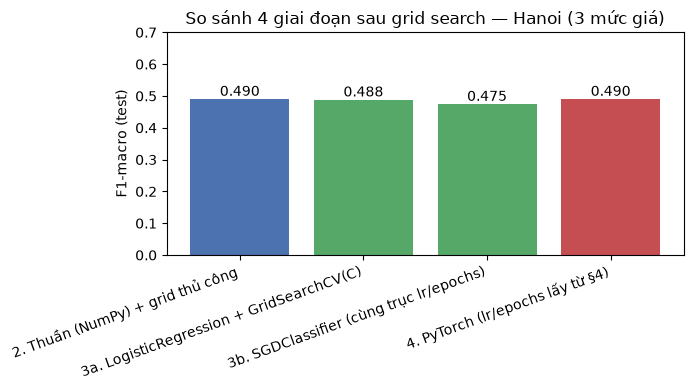

In [8]:
summary = pd.DataFrame([
    {"Giai đoạn": "2. Thuần (NumPy) + grid thủ công", "Best (lr, epochs)": f"({best_lr}, {best_epochs})",
     "Test F1-macro": pure_test_f1, "Test Acc": pure_test_acc},
    {"Giai đoạn": "3a. LogisticRegression + GridSearchCV(C)", "Best (lr, epochs)": f"C={gs_lr.best_params_['C']}",
     "Test F1-macro": lib_lr_f1, "Test Acc": lib_lr_acc},
    {"Giai đoạn": "3b. SGDClassifier (cùng trục lr/epochs)", "Best (lr, epochs)": f"({best_sgd.eta0}, {best_sgd.max_iter})",
     "Test F1-macro": lib_sgd_f1, "Test Acc": lib_sgd_acc},
    {"Giai đoạn": "4. PyTorch (lr/epochs lấy từ §4)", "Best (lr, epochs)": f"({best_lr}, {best_epochs})",
     "Test F1-macro": torch_f1, "Test Acc": torch_acc},
])
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary["Giai đoạn"], summary["Test F1-macro"], color=["#4c72b0", "#55a868", "#55a868", "#c44e52"])
ax.set_ylabel("F1-macro (test)"); ax.set_ylim(0, 0.7)
ax.set_title("So sánh 4 giai đoạn sau grid search — Hanoi (3 mức giá)")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(summary["Test F1-macro"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
fig.tight_layout(); plt.show()

**Nhận xét.**

- Cả 4 cách đều hội tụ về **cùng một trần hiệu năng ~0.49 F1-macro** (thay vì khoảng cách rõ rệt như ở ViHSD). Nguyên nhân: bài toán lồi (3 đặc trưng số, chuẩn hoá) đơn giản đến mức gradient descent — dù thuần hay thư viện — đều tìm ra gần đúng nghiệm tối ưu chỉ sau vài trăm vòng lặp.
- Grid search ở đây **không cải thiện nhiều** so với một cấu hình mặc định hợp lý — vì trần hiệu năng bị chặn bởi **chất lượng đặc trưng**, không phải bởi thuật toán tối ưu. Diện tích, số phòng ngủ, số tầng đơn giản là **không đủ thông tin** để tách 3 mức giá/m² (yếu tố quyết định giá là **vị trí — Quận/Huyện**, đã bị loại khỏi đặc trưng), đúng như phát hiện ở EDA `b1` và ở bài hồi quy `Linear_Regression_Hanoi.ipynb` (R² = 0.071).
- **So sánh với ViHSD:** ở ViHSD, grid search + solver mạnh hơn (LBFGS + L2) tạo khoảng cách F1 rõ rệt (~0.60 → ~0.64) vì bài toán TF-IDF nhiều chiều, khó tối ưu hơn. Ở Hanoi, bài toán ít chiều, lồi "dễ" nên grid search nhanh bão hoà.

**Kết luận:** Grid search là công cụ **tìm hyperparameter tốt nhất có thể với dữ liệu/đặc trưng hiện có** — nó không thay thế được việc **thiết kế đặc trưng tốt hơn** khi trần hiệu năng bị chặn bởi thông tin đầu vào (bài học chung cho cả 2 tập dữ liệu trong bài tập này).